# Robot Shooter Simulator

### Introduction

Every year, the global nonprofit robotics youth organization FIRST creates an esports game for high school students around the world to compete in. In the [2026 season game](https://www.youtube.com/watch?v=_fybREErgyM), teams were asked to build robots that could, among other tasks, shoot foam balls (called Fuel) into goals (called Hubs).

<figure>
    <img src="images/robot-shooting-fuel.jpeg" alt="Image of a robot shooting Fuel into a Hub" width="300" style="display: block; margin: 0 auto;"/>
    <figcaption style="text-align: center; margin-top: 5px;">Robot shooting Fuel into a Hub</figcaption>
</figure>

With this project, I intend to create a kinematic telemetry engine that maps the trajectory of a Fuel into a Hub using interpolation and estimates the Fuel’s total distance traveled using numerical integration.

### Set-Up

This section is dedicated to importing any libraries and other resources (such as images) that we will need later on.

In [1]:
# import libraries
%matplotlib widget
import numpy as np
from scipy import interpolate, integrate
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
# load images (code from Python Graph Gallery; link in References)

# Open an image from a computer 
def open_image_local(path_to_image):
    image = Image.open(path_to_image) # Open the image
    image_array = np.array(image) # Convert to a numpy array
    return image_array # Output

hub = open_image_local("images/hub.png")

### Finding the Maximum Distance Between the Robot and the Hub (inclusive)

To keep things simple, we will assume that our robot will be shooting from directly in front of the Hub. According to the [2026 FRC Game Manual](https://firstfrc.blob.core.windows.net/frc2026/Manual/2026GameManual.pdf), the distance between the wall and the front of the Hub is 158.6 inches, as shown below.

<figure>
    <img src="images/figure-5-6.png" alt="Figure showing distance between field wall and Hub" width="300" style="display: block; margin: 0 auto;"/>
    <figcaption style="text-align: center; margin-top: 5px;">Figure 5-6 in FRC Game Manual: Hub distance to wall</figcaption>
</figure>

You may notice that there is a structure in the middle of the field against the wall. This structure is called a Tower, and since it is positioned directly across the Hub, it reduces the amount of space a robot would have. The manual describes the Tower's base to be 45.18 inches deep, which we can subtract from the previously mentioned 158.6 inches.

Our final step is to include the size of the Hub in our calculations, since our robot will be shooting *into* the Hub and not in front of it. We can once again refer to the manual to determine the Hub's base is 47 inches wide:

<figure>
    <img src="images/figure-5-7.png" alt="Figure showing Hub dimensions" width="300" style="display: block; margin: 0 auto;"/>
    <figcaption style="text-align: center; margin-top: 5px;">Figure 5-7 in FRC Game Manual: Hub dimensions</figcaption>
</figure>

We'll add a buffer of 13 inches to include the net in the back, estimating the total width to be 60 inches. This makes our final distance 158.6 in - 45.18 in + 60 in.

Our maximum distance is therefore 173.42 inches.

### Trajectory

We begin by approximating the trajectory of the ball. Given a set of user-defined points, we will return a graph that maps a path along those points. We will compare two interpolation methods: spline interpolation and Newton's divided difference.

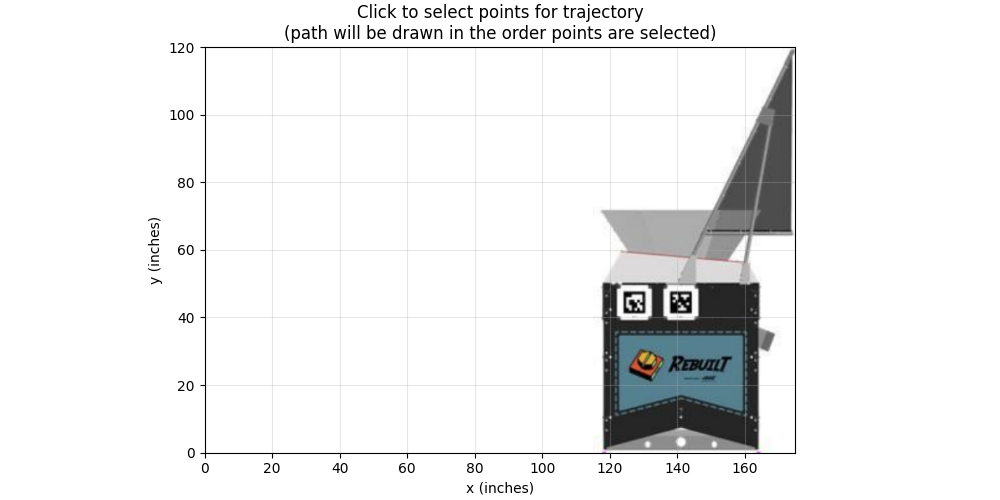

In [3]:
# resets figure (deletes previously run figures)
plt.close('all')

# draw figure
fig, ax = plt.subplots(layout = 'constrained')
fig.set_size_inches(10, 5)
ax.set_xlim(0, 175)
ax.set_ylim(0, 120)
ax.grid(True, alpha = 0.3)
ax.set_aspect('equal')
ax.set_title("Click to select points for trajectory\n(path will be drawn in the order points are selected)")
ax.set_xlabel("x (inches)")
ax.set_ylabel("y (inches)")

# insert image of hub (positioned by its true aspect ratio)
# pixel dimensions of image
img_height, img_width = hub.shape[:2]

# hub bottom-left corner coordinates
x_start = 115
y_start = 0

# calculate top-right corner coordinates based on pixel dimensions and scale factor
scale = 0.24
x_end = x_start + (img_width * scale)
y_end = y_start + (img_height * scale)

ax.imshow(hub, extent = [x_start, x_end, y_start, y_end], aspect = 'equal', zorder = 0)

points_x = []
points_y = []

def onclick(event):
    # if point within valid range (inside axes)
    if event.inaxes is not None:
        # store point coordinates
        x, y = event.xdata, event.ydata
        points_x.append(x)
        points_y.append(y)
        
        # draw new point on plot (event.inaxes ensures point shows whether drawn on main axes or image axes)
        event.inaxes.plot(x, y, 'om')
        fig.canvas.draw()
        
        # Stop after 5 points
        if len(points_x) >= 5:
            fig.canvas.mpl_disconnect(cid)

# connect event to function
cid = fig.canvas.mpl_connect('button_press_event', onclick)

The image of the Hub has been scaled to be approximately accurate to its real-life dimensions.

In [4]:
print("Coordinates of selected points (x, y):")
for i in range(5):
    print("(", float(points_x[i]), ",", float(points_y[i]), ")")

Coordinates of selected points (x, y):
( 21.316211705324733 , 24.577782837644897 )
( 45.730675831804945 , 55.1694005382948 )
( 78.96964506424185 , 88.99667011112882 )
( 114.85596582846578 , 89.2908202813274 )
( 131.6225255297835 , 76.34821279259089 )


##### Spline Interpolation

We will begin with spline interpolation. Specifically, we'll be using natural cubic spline; a local piecewise interpolation method that fits a cubic polynomial between each pair of points. It is superior to linear and quadratic spline interpolation as it ensures both continuity and smoothness between points. Below is a graph showing cubic vs linear interpolation of the selected points for comparison:

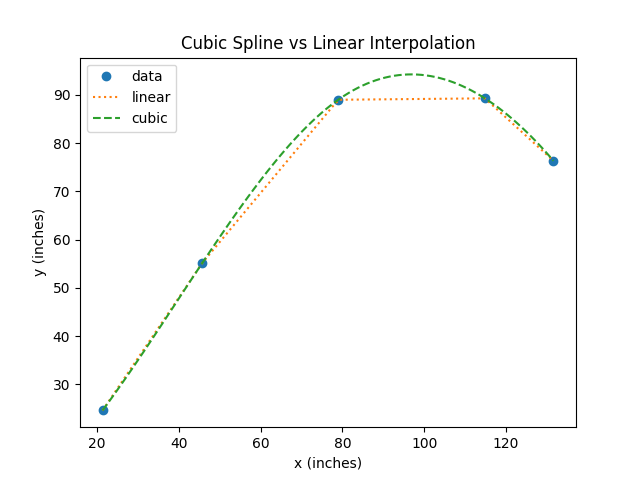

In [5]:
l_spline = interpolate.interp1d(points_x, points_y) # default is linear
c_spline = interpolate.CubicSpline(points_x, points_y)

# use dense set of x values to plot smooth curves
x_dense = np.linspace(min(points_x), max(points_x), num = 100, endpoint = True)

plt.figure()
plt.plot(points_x, points_y, 'o', x_dense, l_spline(x_dense), ':', x_dense, c_spline(x_dense), '--')
plt.title("Cubic Spline vs Linear Interpolation")
plt.xlabel("x (inches)")
plt.ylabel("y (inches)")
plt.legend(['data', 'linear', 'cubic'], loc = 'best')

Let's see how the cubic spline looks with the hub included:

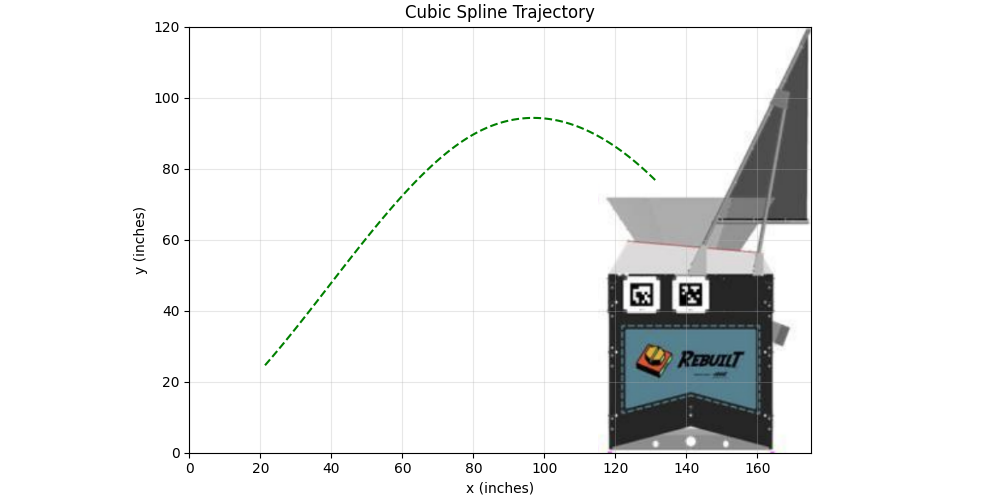

In [6]:
fig, ax = plt.subplots(layout = 'constrained')
fig.set_size_inches(10, 5)
ax.plot(x_dense, c_spline(x_dense), 'g--')
ax.set_xlim(0, 175)
ax.set_ylim(0, 120)
ax.grid(True, alpha = 0.3)
ax.set_aspect('equal')
ax.set_title("Cubic Spline Trajectory")
ax.set_xlabel("x (inches)")
ax.set_ylabel("y (inches)")

ax.imshow(hub, extent = [x_start, x_end, y_start, y_end], aspect = 'equal')

##### Newton's Divided Difference

As mentioned before, our second method of approximating the trajectory is Newton's divided difference. Unlike cubic spline, Newton’s divided difference is a global polynomial interpolation method. This means it constructs a single polynomial that passes through all of the data points simultaneously.

The general form of an $n - 1$ order Newton's polynomial going through $n$ points is:
$$f(x) = a_0 + a_1(x - x_0) + a_2(x - x_0)(x - x_1) + ... + a_n(x - x_0)(x - x_1)...(x - x_{n-1})$$
where, if $f[x_1, x_0] = \frac{y_1 - y_0}{x_1 - x_0}$, the coefficients $a_i$ are computed by:
$$a_i = f[x_i, x_{i - 1}, ... , x_1, x_0] = \frac{f[x_i, x_{i - 1}, ... , x_2, x_1] - f[x_{i - 1}, x_{i - 2}, ... , x_1, x_0]}{x_i - x_0}$$

In [7]:
# here, we define the functions to construct and evaluatie the Newton's polynomial
# code for Newton's divided differences from Python Numerical Methods (link in References)

# function to calculate divided differences table
def divided_diff(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:,0] = y # first column is y values
    
    for j in range(1,n):
        for i in range(n-j):
            coef[i][j] = \
           (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j]-x[i])
            
    return coef

# function to evaluate the newton polynomial at x
def newton_poly(coef, x_data, x):
    n = len(x_data) - 1 
    p = coef[n]
    for k in range(1,n+1):
        p = coef[n-k] + (x -x_data[n-k])*p
    return p

We'll plot the graph created by the Newton's polynomial, again with the image of the Hub included:

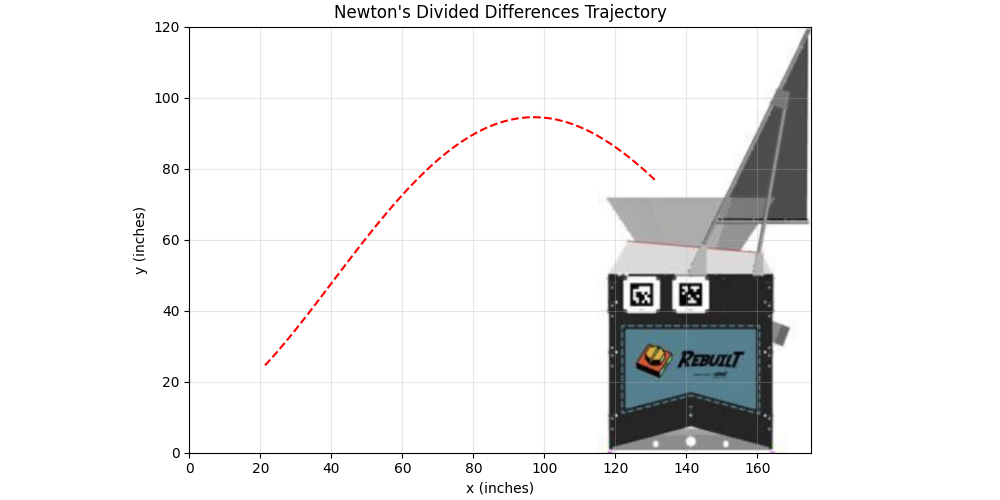

In [8]:
a_s = divided_diff(points_x, points_y)[0, :] # coefficients

fig, ax = plt.subplots(layout = 'constrained')
fig.set_size_inches(10, 5)
ax.plot(x_dense, newton_poly(a_s, points_x, x_dense), 'r--')
ax.set_xlim(0, 175)
ax.set_ylim(0, 120)
ax.grid(True, alpha = 0.3)
ax.set_aspect('equal')
ax.set_title("Newton's Divided Differences Trajectory")
ax.set_xlabel("x (inches)")
ax.set_ylabel("y (inches)")

ax.imshow(hub, extent = [x_start, x_end, y_start, y_end], aspect = 'equal')

##### Comparing the Interpolation Methods
Let's compare the graphs produced by the natural cubic spline and Newton's polynomial to see which curve was smoother and more realistic:

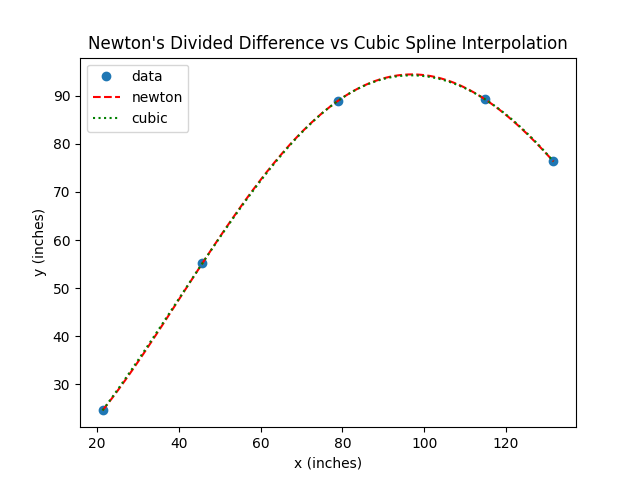

In [9]:
# compare newton's divided difference to cubic spline
plt.figure()
plt.plot(points_x, points_y, 'o', x_dense, newton_poly(a_s, points_x, x_dense), 'r--', x_dense, c_spline(x_dense), 'g:')
plt.title("Newton's Divided Difference vs Cubic Spline Interpolation")
plt.xlabel("x (inches)")
plt.ylabel("y (inches)")
plt.legend(['data', 'newton', 'cubic'], loc = 'best')

Survey says...they're practically the same.

### Velocity

In [10]:
# ask user for total duration of path (e.g., 2.0 seconds)
total_time = 2.0
# build evenly spaced time stamps between selected points (assumes points are reached at evenly spaced time intervals)
time = np.linspace(0, total_time, len(points_x))

pos = interpolate.CubicSpline(time, np.column_stack((points_x, points_y)), axis = 0)
vel = pos.derivative()

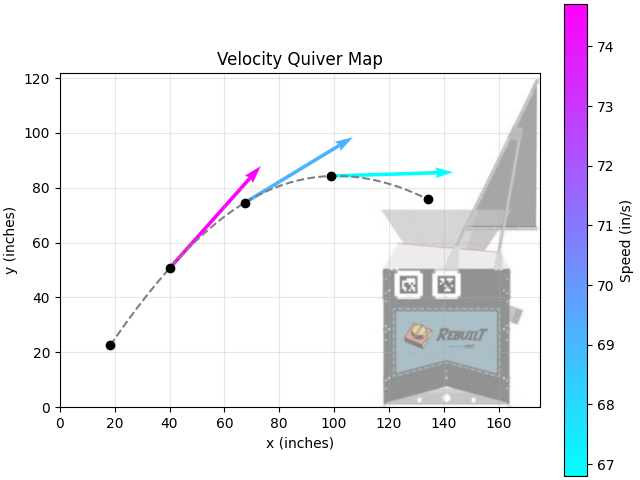

In [11]:
# plot path and velocity arrows
time_dense = np.linspace(0, total_time, num = 100, endpoint = True)
pos_dense = pos(time_dense)
path_x = pos_dense[:, 0]
path_y = pos_dense[:, 1]

# arrow positions (evaluate at exact data indices to avoid overcrowding with overlapping arrows)
arrow_positions = pos(time[1:-1]) # exclude first and last points
x_pos = arrow_positions[:, 0]
y_pos = arrow_positions[:, 1]

# generate velocity arrows
arrow_velocities = vel(time[1:-1]) # exclude first and last points
vx_arrow = arrow_velocities[:, 0]
vy_arrow = arrow_velocities[:, 1]

# speed = magnitude of velocity vector
speed = np.sqrt(vx_arrow**2 + vy_arrow**2)

fig, ax = plt.subplots(layout = 'constrained')
# show underlying path and selected points
ax.plot(path_x, path_y, color = 'gray', linestyle = '--')
ax.scatter(points_x, points_y, color = 'black', zorder = 5)

quiver = ax.quiver(x_pos, y_pos, vx_arrow, vy_arrow, speed, cmap = 'cool', angles = 'xy', scale_units = 'xy', scale = 1.5)

ax.set_xlim(0, 175)
ax.grid(True, alpha = 0.3)
ax.set_aspect('equal') 
ax.set_xlabel('x (inches)')
ax.set_ylabel('y (inches)')
ax.set_title('Velocity Quiver Map')
plt.colorbar(quiver, label = 'Speed (in/s)')

ax.imshow(hub, extent = [x_start, x_end, y_start, y_end], aspect = 'equal', alpha = 0.5)

### Total Distance Traveled

The total distance $D$ traveled over a time interval [$t_0$, $t_f$] is the integral of total speed over time:
$$\int_{t_0}^{t_f} speed\ dt = \int_{t_0}^{t_f} ||velocity||\ dt = \int_{t_0}^{t_f}\sqrt{(vx)^2 + (vy)^2}dt$$
This integral is rather messy to solve analytically, so it is best to integrate numerically.

Text(0.5, 1.0, 'Speed vs Time')

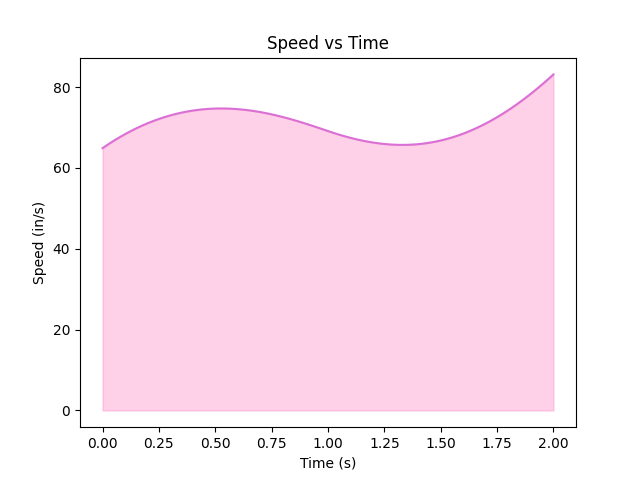

In [12]:
vel_dense = vel(time_dense)
vx = vel_dense[:, 0]
vy = vel_dense[:, 1]
speed_dense = np.sqrt(vx**2 + vy**2)

plt.figure()
plt.plot(time_dense, speed_dense, color = 'orchid')
plt.fill_between(time_dense, speed_dense, color = 'hotpink', alpha = 0.3)
plt.xlabel('Time (s)')
plt.ylabel('Speed (in/s)')
plt.title('Speed vs Time')

##### Simpson's 1/3 Rule

Because the path of the Fuel is typically a parabola, we will utilize Simpson's 1/3 rule rather than 3/8.

In [13]:
print("Simpson:", integrate.simpson(speed_dense, time_dense), "inches")

Simpson: 142.08727394879185 inches


##### Gauss-Legendre Quadrature

In [21]:
def speed_function(t):
    vel_t = vel(t)
    vx_t = vel_t[:, 0]
    vy_t = vel_t[:, 1]
    return np.sqrt(vx_t**2 + vy_t**2)

print("Gauss-Legendre Quadrature:", integrate.fixed_quad(speed_function, 0, total_time)[0], "inches")

Gauss-Legendre Quadrature: 142.06923582861847 inches


##### Gauss–Kronrod Quadrature

In [15]:
def speed_function(t):
    vel_t = vel(t)
    vx_t = vel_t[0]
    vy_t = vel_t[1]
    return np.sqrt(vx_t**2 + vy_t**2)

print("Gauss-Kronrod Quadrature (adaptive variant of Gaussian):", integrate.quad(speed_function, 0, total_time)[0], "inches")

Gauss-Kronrod Quadrature (adaptive variant of Gaussian): 142.0872663184912 inches


### References

- https://www.youtube.com/watch?v=_fybREErgyM (context)
- https://www.thebluealliance.com/team/27 (image)
- https://firstfrc.blob.core.windows.net/frc2026/Manual/2026GameManual.pdf (calculations, images)
- https://python-graph-gallery.com/513-add-logo-matplotlib/ (code)
- https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter17.05-Newtons-Polynomial-Interpolation.html (code)